## Augmented Binary Encoding

Sensor count: $ 2 + 4 + 8 + ...$


010000
000001

                > 010001

                000011        010011

                > 010010

010000         010100         010110
000100         110000         110010        110110
001000         000110         110100
100000         100010         100110

                > 100100

                001100         101100

                > 101000

001000
100000


## Redundant Binary Encoding

Sensor count: $ 2 + 2 + 2 + ... $

> 0101

> 0110



> 1001

> 1010


## Non-redundant Binary Encoding

Sensor count: $1 + 1 + 1 + ...$

Saved image successfully


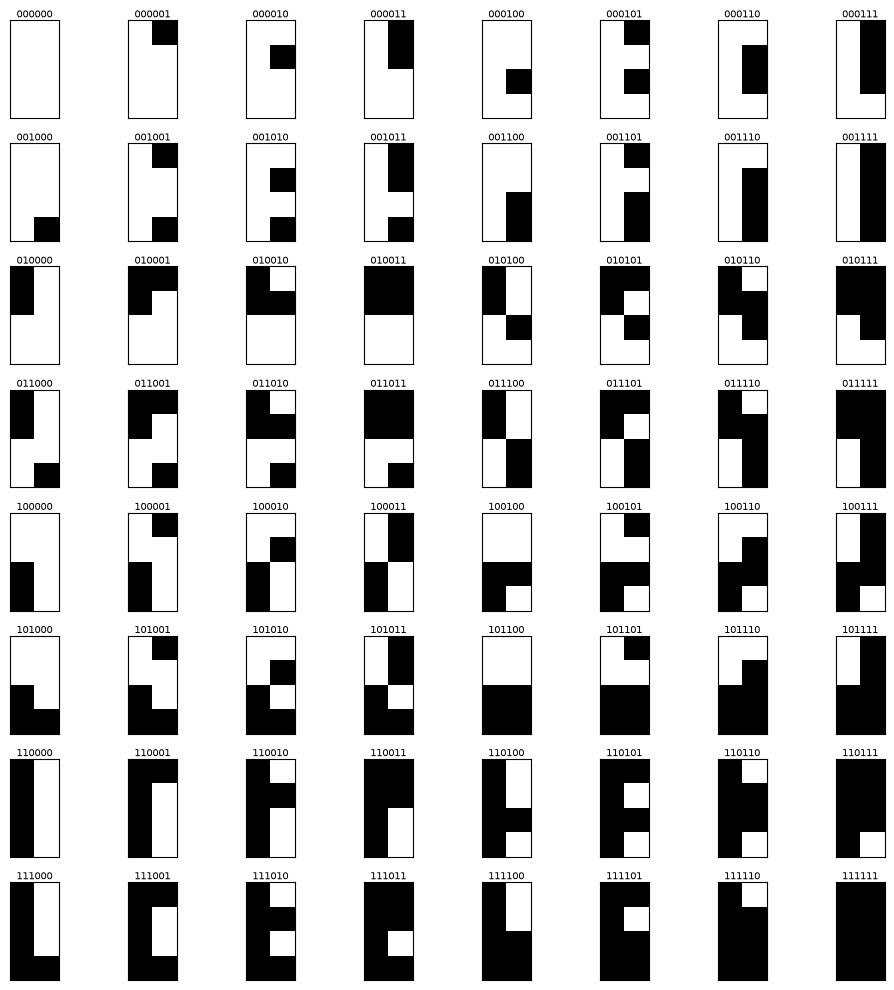

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for val in range(64):
    row_idx = val // 8
    col_idx = val % 8
    ax = axes[row_idx, col_idx]
    
    # Create 4x2 array (4 rows, 2 columns) initialized to light (e.g. 1.0 for white)
    # Note: array shape is (rows, cols) = (4, 2)
    # y is row index (0..3), x is col index (0..1)
    grid = np.ones((4, 2))
    
    # Check bit masks
    if val & 0b010000:
        grid[0, 0] = 0.0 # dark
        grid[1, 0] = 0.0 # dark
    if val & 0b100000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
        
    if val & 0b000001:
        grid[0, 1] = 0.0
    if val & 0b000010:
        grid[1, 1] = 0.0
    if val & 0b000100:
        grid[2, 1] = 0.0
    if val & 0b001000:
        grid[3, 1] = 0.0

    ax.imshow(grid, cmap='gray', vmin=0, vmax=1, origin='upper')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{val:06b}", fontsize=7, pad=2)

plt.tight_layout()
plt.savefig("binary_states.png", dpi=150)
print("Saved image successfully")

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Map 6-bit to 4-bit according to the user's instructions:
# 6-bit value: b5 b4 b3 b2 b1 b0
# b5 -> 4-bit bit 3 (0b1000)
# b4 -> 4-bit bit 2 (0b0100)
# b3 OR b1 -> 4-bit bit 1 (0b0010)
# b2 OR b0 -> 4-bit bit 0 (0b0001)

def six_to_four(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    
    bit0 = b0 | b2
    bit1 = b1 | b3
    bit2 = b4
    bit3 = b5
    
    return (bit3 << 3) | (bit2 << 2) | (bit1 << 1) | bit0

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = six_to_four(v6)
    mapping[v4].append(v6)

for v4, v6_list in mapping.items():
    print(f"4-bit {v4:04b} ({v4:2d}): {len(v6_list)} items -> {[f'{v:06b}' for v in v6_list]}")

4-bit 0000 ( 0): 1 items -> ['000000']
4-bit 0001 ( 1): 3 items -> ['000001', '000100', '000101']
4-bit 0010 ( 2): 3 items -> ['000010', '001000', '001010']
4-bit 0011 ( 3): 9 items -> ['000011', '000110', '000111', '001001', '001011', '001100', '001101', '001110', '001111']
4-bit 0100 ( 4): 1 items -> ['010000']
4-bit 0101 ( 5): 3 items -> ['010001', '010100', '010101']
4-bit 0110 ( 6): 3 items -> ['010010', '011000', '011010']
4-bit 0111 ( 7): 9 items -> ['010011', '010110', '010111', '011001', '011011', '011100', '011101', '011110', '011111']
4-bit 1000 ( 8): 1 items -> ['100000']
4-bit 1001 ( 9): 3 items -> ['100001', '100100', '100101']
4-bit 1010 (10): 3 items -> ['100010', '101000', '101010']
4-bit 1011 (11): 9 items -> ['100011', '100110', '100111', '101001', '101011', '101100', '101101', '101110', '101111']
4-bit 1100 (12): 1 items -> ['110000']
4-bit 1101 (13): 3 items -> ['110001', '110100', '110101']
4-bit 1110 (14): 3 items -> ['110010', '111000', '111010']
4-bit 1111 (15)

Image saved successfully.


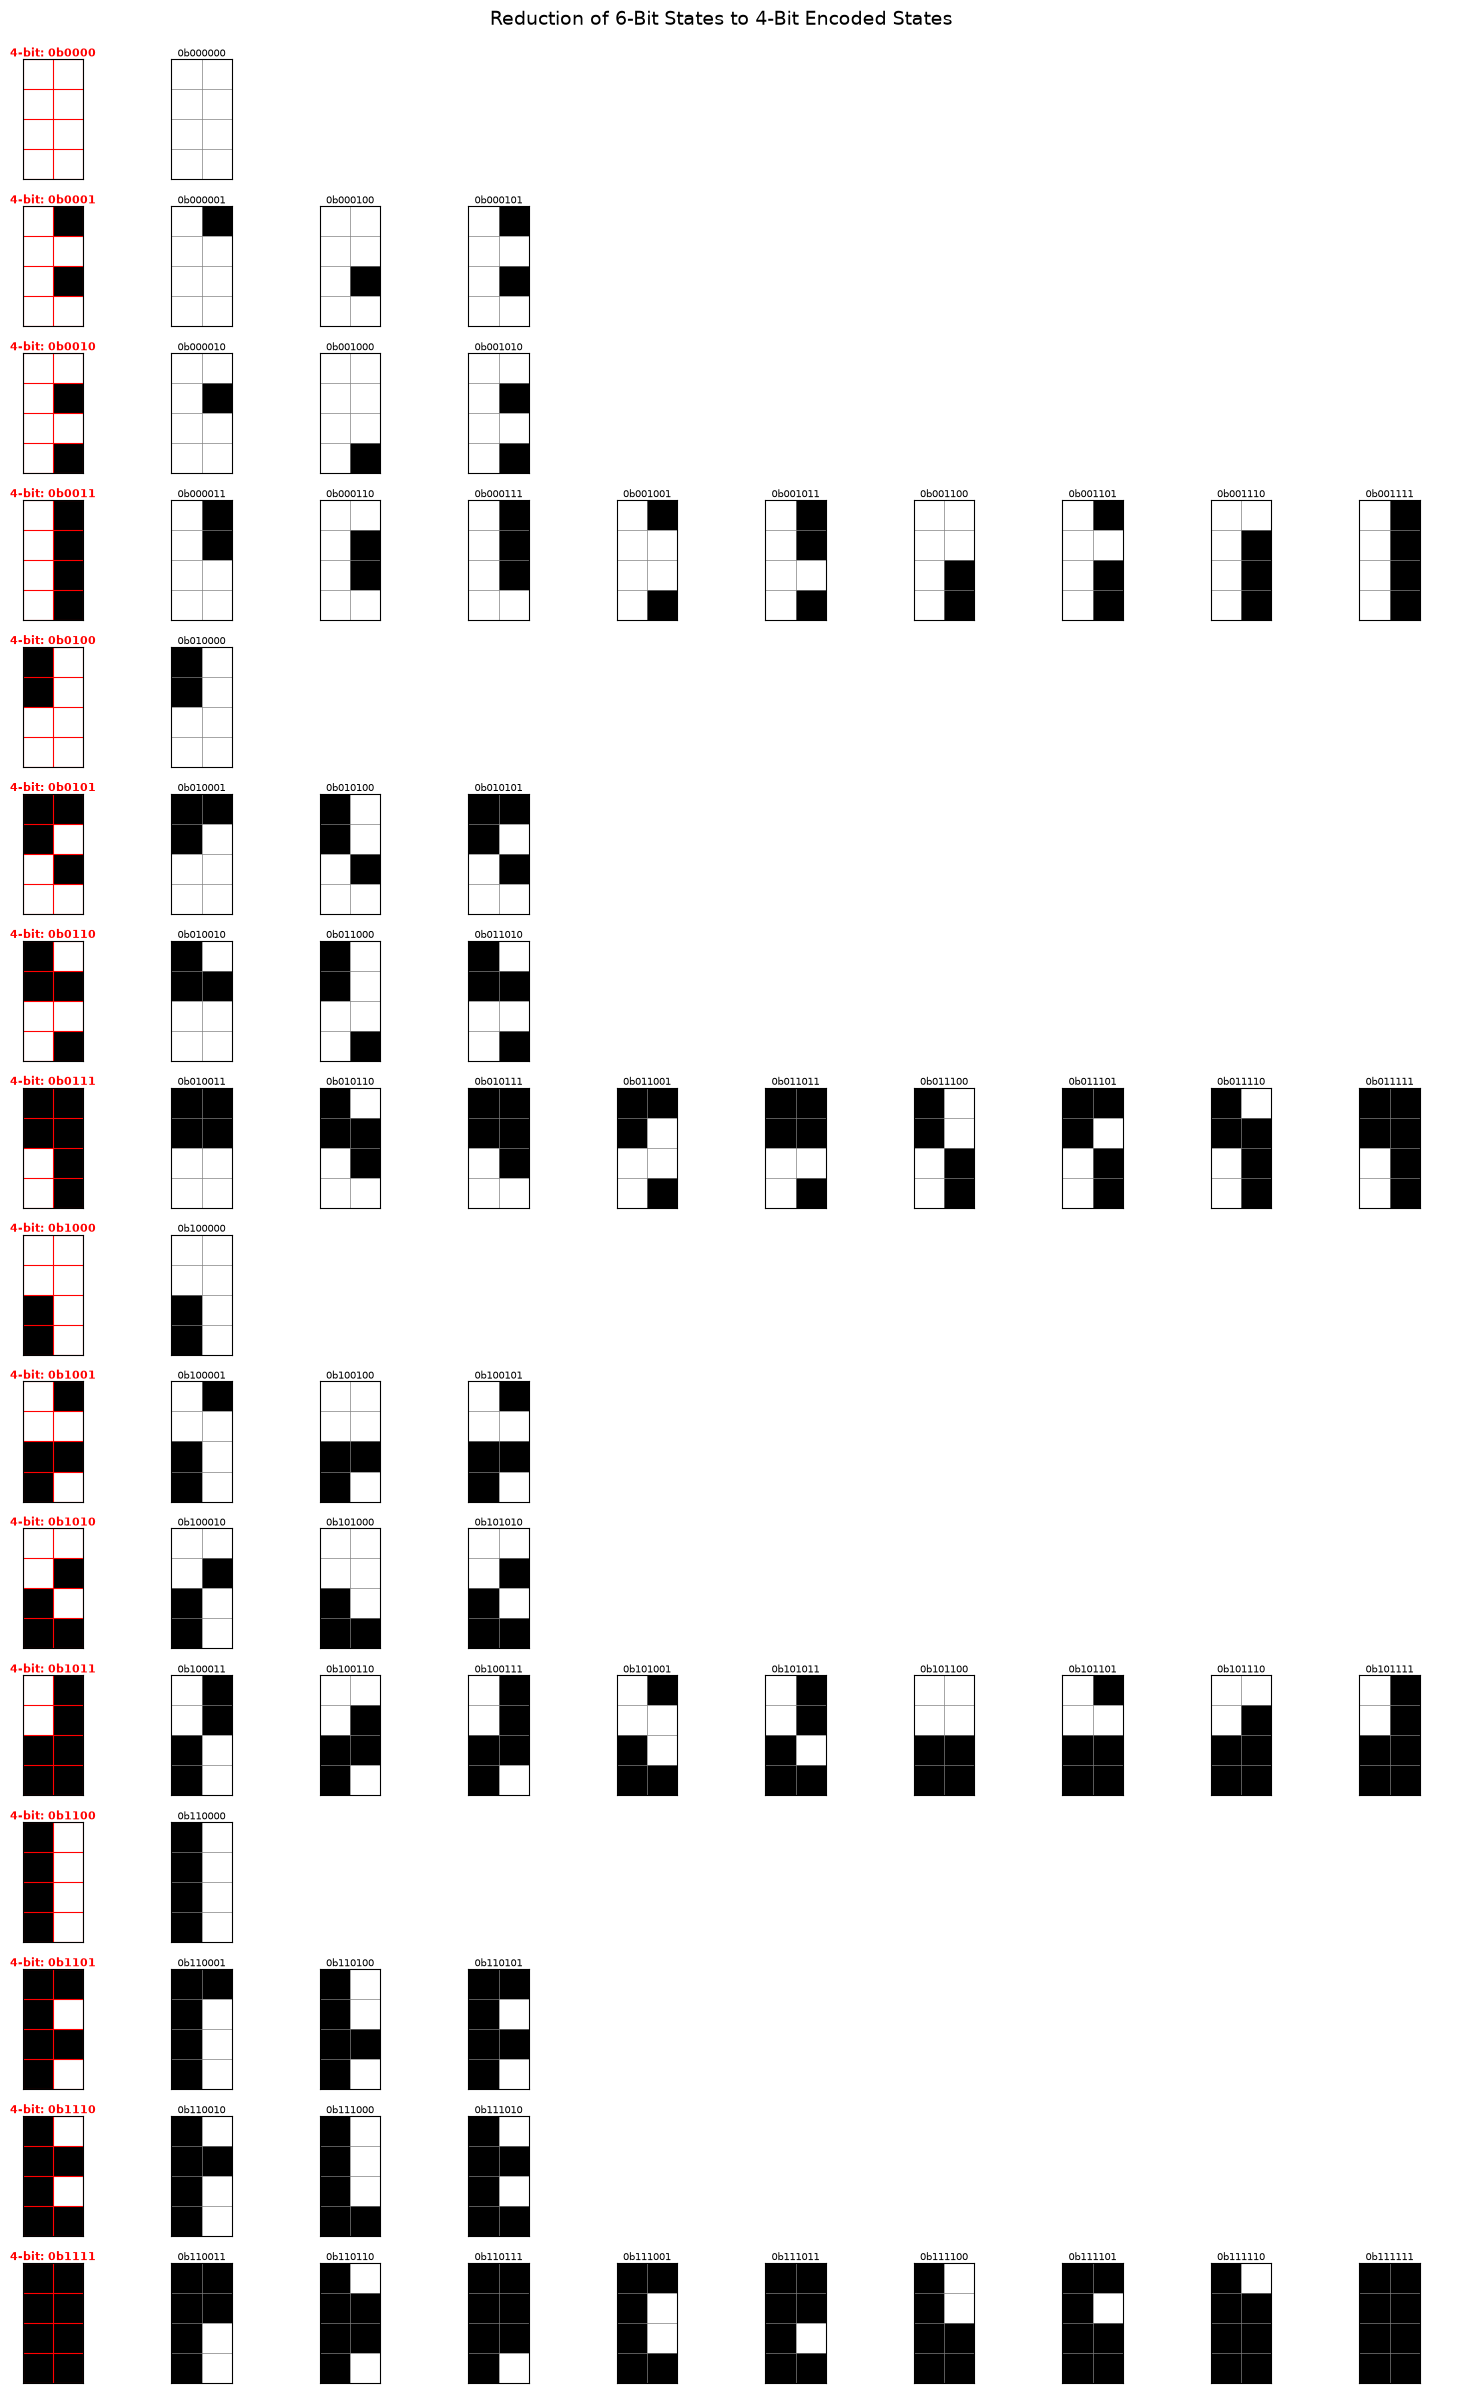

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def draw_4bit_grid(v4):
    grid = np.ones((4, 2))
    # Bit 2 (0b0100): (0,0) and (0,1)
    if v4 & 0b0100:
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    # Bit 3 (0b1000): (0,2) and (0,3)
    if v4 & 0b1000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    # Bit 0 (0b0001): (1,0) and (1,2)
    if v4 & 0b0001:
        grid[0, 1] = 0.0
        grid[2, 1] = 0.0
    # Bit 1 (0b0010): (1,1) and (1,3)
    if v4 & 0b0010:
        grid[1, 1] = 0.0
        grid[3, 1] = 0.0
    return grid

def draw_6bit_grid(v6):
    grid = np.ones((4, 2))
    if v6 & 0b010000:
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    if v6 & 0b100000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    if v6 & 0b000001:
        grid[0, 1] = 0.0
    if v6 & 0b000010:
        grid[1, 1] = 0.0
    if v6 & 0b000100:
        grid[2, 1] = 0.0
    if v6 & 0b001000:
        grid[3, 1] = 0.0
    return grid

def six_to_four(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    
    bit0 = b0 | b2
    bit1 = b1 | b3
    bit2 = b4
    bit3 = b5
    
    return (bit3 << 3) | (bit2 << 2) | (bit1 << 1) | bit0

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = six_to_four(v6)
    mapping[v4].append(v6)

fig, axes = plt.subplots(16, 10, figsize=(15, 24))

for row_idx in range(16):
    v4 = row_idx
    v6_list = mapping[v4]
    
    # Col 0: 4-bit state
    ax = axes[row_idx, 0]
    grid_4 = draw_4bit_grid(v4)
    ax.imshow(grid_4, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax.set_xticks(np.arange(0, 3, 1))
    ax.set_yticks(np.arange(0, 5, 1))
    ax.grid(color='red', linestyle='-', linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.set_title(f"4-bit: 0b{v4:04b}", fontsize=8, color='red', weight='bold', pad=2)
    
    # Cols 1..9: matching 6-bit states
    for col_idx in range(1, 10):
        ax_sub = axes[row_idx, col_idx]
        if col_idx - 1 < len(v6_list):
            v6 = v6_list[col_idx - 1]
            grid_6 = draw_6bit_grid(v6)
            ax_sub.imshow(grid_6, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
            ax_sub.set_xticks(np.arange(0, 3, 1))
            ax_sub.set_yticks(np.arange(0, 5, 1))
            ax_sub.grid(color='gray', linestyle='-', linewidth=0.5)
            ax_sub.set_xticklabels([])
            ax_sub.set_yticklabels([])
            ax_sub.tick_params(length=0)
            ax_sub.set_title(f"0b{v6:06b}", fontsize=7, pad=2)
        else:
            # Empty plot slot
            ax_sub.axis('off')

plt.suptitle("Reduction of 6-Bit States to 4-Bit Encoded States", fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig("reduced_4bit_mapping.png", dpi=150, bbox_inches='tight')
print("Image saved successfully.")

## Ambiguity Types for Augmented Binary Encoding

- Contiguous trigger ambiguity: single-bit, dual-bit (single layer), triple bit.
    - Two trigger sections that are not connected (not considering diagonals)
- Disjointed trigger ambiguity: dual-bit, triple bit, quad bit.
